In [3]:
from rajib_pca import *
from sklearn.preprocessing import MinMaxScaler
from helper_predict import *
from chronos import BaseChronosPipeline, Chronos2Pipeline
import pandas as pd


### Data path

In [4]:
# data_path = "/home/rajib/mTSBench/Datasets/mTSBench/SMD/SMD_machine-1-6_test.csv"
data_path = "/home/rajib/mTSBench/Datasets/mTSBench/Exathlon/Exathlon_6_3_200000_76_test.csv"
SPLIT_RATIO = 0.5

### PCA output

In [5]:

# data_path_Exathlon = "/home/rajib/mTSBench/Datasets/mTSBench/Exathlon/*test.csv"
anomaly_score, result = anomaly_PCA(data_path, SPLIT_RATIO)
scaler = MinMaxScaler()
anomaly_score_scaled = scaler.fit_transform(anomaly_score.reshape(-1, 1)).flatten()

print(f"for pca the anomaly score matrix shape is {anomaly_score.shape}")


for pca the anomaly score matrix shape is (18662,)


In [6]:
print(f'PCA-auroc: {result["AUC-ROC"]}')

PCA-auroc: 0.8147261690097292


### Chronos output

In [7]:
df_original = pd.read_csv(data_path)
df_original = prepare_df_test(df_original)
df_train, df_test = split_dataset(df_original, SPLIT_RATIO)
df_train["id"] = "SMD"
df_test["id"]  = "SMD"

feature_list = [
        c for c in df_original.columns
        if c not in ["timestamp", "is_anomaly"]
    ]

pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-2",
    device_map="cuda"
)


In [8]:
chronos_pred = generate_prediction(pipeline,
                                   df_train,
                                   df_test,
                                   feature_list,
                                   30,
                                   1024)

In [9]:
feature_groups = {
    feature: group.reset_index(drop=True) 
    for feature, group in chronos_pred.groupby("target_name")
}
# print(f"for chronos the prediction matrix shape is {feature_groups['feature_1'].shape}")

In [33]:
anomaly_scores = {}

for feature_name, group_df in chronos_pred.groupby("target_name"):
    group_df = group_df.reset_index(drop=True)
    y_actual = df_test[feature_name].values

    score = compute_feature_score(y_actual, group_df, method='mse')
    anomaly_scores[feature_name] = score


anomaly_df = pd.DataFrame(anomaly_scores)
anomaly_df = anomaly_df.fillna(0)

anomaly_df = anomaly_df.apply(
    lambda col: pd.Series(robust_normalize(col.values)), axis=0
)
y_score = aggregate_scores(anomaly_df, method='L2')

y_true = df_test["is_anomaly"].values
y_score_scaled = (y_score - y_score.min()) / (y_score.max() - y_score.min())

auroc = roc_auc_score(y_true, y_score)
auprc = average_precision_score(y_true, y_score)
print(f"AUROC: {auroc:.4f} | AUPRC: {auprc:.4f}")

AUROC: 0.4615 | AUPRC: 0.0927


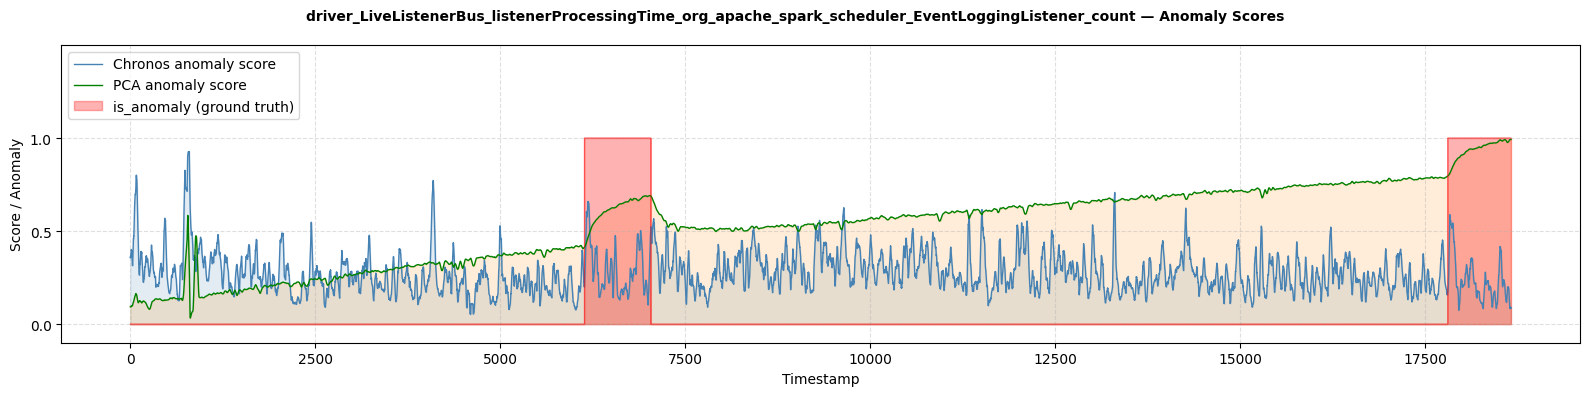

In [11]:
plot_pca_chronos_anomaly(feature_groups,
                          df_test,
                          y_score,
                           anomaly_score_scaled,
                           feature_idx=1, plot_from=None, plot_until=None, smooth_window=30)

In [15]:
# for i in range(0,39):
#     plot_pca_chronos_anomaly(feature_groups,
#                           df_test,
#                           y_score,
#                            anomaly_score_scaled,
#                            feature_idx=i, plot_from=None, plot_until=None, smooth_window=30)

### Trasform chronos score distribution

In [ ]:


# def reshape_chronos_scores(scores):
#     # Clip to avoid log(0)
#     scores_clipped = np.clip(scores, 1e-8, 1.0)
    
#     # Log transform stretches the compressed left tail
#     log_scores = -np.log(scores_clipped)  # negated: high score = more anomalous
    
#     # Rescale to [0, 1]
#     log_scores = (log_scores - log_scores.min()) / \
#                  (log_scores.max() - log_scores.min())
#     return log_scores

# y_score = reshape_chronos_scores(y_score)



# from sklearn.preprocessing import PowerTransformer

# pt = PowerTransformer(method='yeo-johnson', standardize=False)
# chronos_transformed = pt.fit_transform(y_score.reshape(-1, 1)).flatten()

# # Rescale back to [0,1]
# y_score = (chronos_transformed - chronos_transformed.min()) / \
#                       (chronos_transformed.max() - chronos_transformed.min())



# from sklearn.isotonic import IsotonicRegression
# from sklearn.calibration import calibration_curve

# # Fit isotonic regression to map Chronos → calibrated scores
# ir = IsotonicRegression(increasing=True, out_of_bounds='clip')
# ir.fit(y_score, y_true)  # labels: 0=normal, 1=anomaly

# y_score = ir.predict(y_score)


# def amplify_tail(scores, threshold_percentile=70, power=2.0):
#     threshold = np.percentile(scores, threshold_percentile)
    
#     amplified = np.where(
#         scores > threshold,
#         threshold + (scores - threshold) ** (1/power),  # stretch high scores
#         scores * 0.5   # suppress low scores further
#     )
#     # Rescale
#     return (amplified - amplified.min()) / (amplified.max() - amplified.min())

# y_score = amplify_tail(y_score)

In [32]:
auroc = roc_auc_score(y_true, y_score)
print(auroc)

0.553281099993769


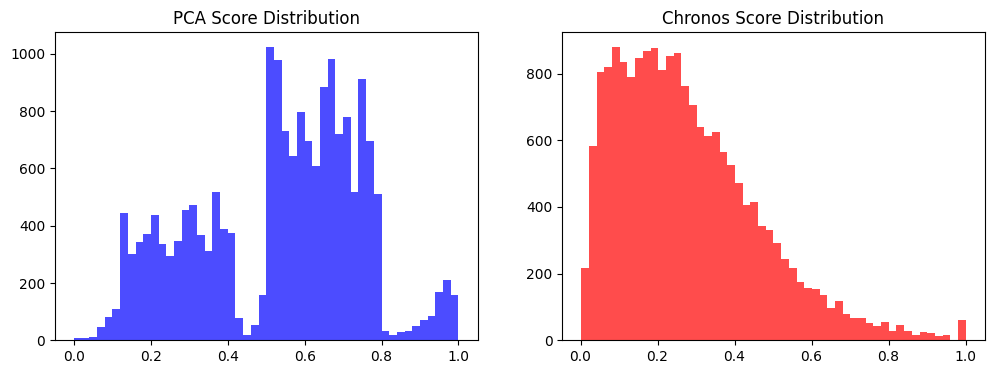

In [35]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Check score contrast
# print("PCA   - std:", np.std(anomaly_score_scaled), 
#                 " | max-min:", np.max(anomaly_score_scaled) - np.min(anomaly_score_scaled))
# print("Chronos - std:", np.std(y_score),
#                 " | max-min:", np.max(y_score) - np.min(y_score))

# Plot histogram side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(anomaly_score_scaled, bins=50, color='blue', alpha=0.7)
axes[0].set_title("PCA Score Distribution")
axes[1].hist(y_score, bins=50, color='red', alpha=0.7)
axes[1].set_title("Chronos Score Distribution")
plt.show()